# **Reading the Dataset**

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

obesity_data = pd.read_csv('C:\\Users\\Lycan\\Desktop\\obesity_data.csv')
obesity_data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# **Removing Duplicates**

In [2]:
obesity_data = pd.read_csv('C:\\Users\\Lycan\\Desktop\\obesity_data.csv', encoding='latin')
print('Shape before deleting duplicate values:', obesity_data.shape)

# Removing duplicate rows if any
obesity_data=obesity_data.drop_duplicates()
print('Shape After deleting duplicate values:', obesity_data.shape)

obesity_data.head(10)

Shape before deleting duplicate values: (2111, 17)
Shape After deleting duplicate values: (2087, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


# **Defining the problem statement**

build a classification model to predict an individual’s obesity category (e.g., Normal Weight, Overweight, Obesity) based on eating habits, physical activity, and lifestyle factors. Perform exploratory data analysis, preprocess and encode features, train multiple classification models, evaluate performance, and identify the most influential factors affecting obesity levels.

Target Variable: NObeyesdad

\
Which contains the obesity category labels like Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, etc.

\
Based on the problem statement you can understand that we need to create a supervised ML classification model



Why it's supervised classification:

*The target is categorical (discrete classes, not a number)

*The labels are already provided in the data (supervised, we have the answers to learn from)

*The goal is to predict which class a new individual belongs to



# **Looking at the distribution of Target variable**

The Target variable distribution looks balanced.
There are enough number of rows for each values for the ML algorithms to learn.
Hence we can go ahead


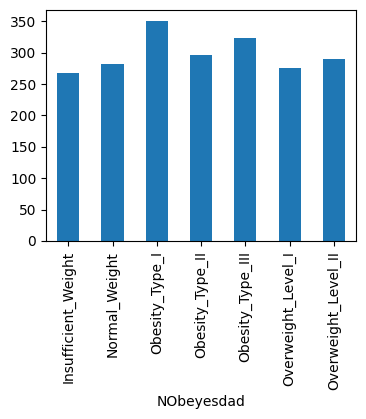

In [3]:
GroupedData=obesity_data.groupby('NObeyesdad').size()
GroupedData.plot(kind='bar', figsize=(4,3))


print('''The Target variable distribution looks balanced.
There are enough number of rows for each values for the ML algorithms to learn.
Hence we can go ahead''')

# **Basic Data Exploration**

In [4]:
obesity_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   object 
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   object 
 5   FAVC                            2087 non-null   object 
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   object 
 9   SMOKE                           2087 non-null   object 
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   object 
 12  FAF                             2087 no

In [5]:
obesity_data.describe(include='all')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2087,2087.000000,2087.000000,2087.000000,2087,2087,2087.000000,2087.000000,2087,2087,2087.000000,2087,2087.000000,2087.000000,2087,2087,2087
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1052,NaN,NaN,NaN,1722,1844,NaN,NaN,1761,2043,NaN,1991,NaN,NaN,1380,1558,351
mean,NaN,24.353090,1.702674,86.858730,NaN,NaN,2.421466,2.701179,NaN,NaN,2.004749,NaN,1.012812,0.663035,NaN,NaN,NaN
std,NaN,6.368801,0.093186,26.190847,NaN,NaN,0.534737,0.764614,NaN,NaN,0.608284,NaN,0.853475,0.608153,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.915937,1.630178,66.000000,NaN,NaN,2.000000,2.697467,NaN,NaN,1.590922,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.847618,1.701584,83.101100,NaN,NaN,2.396265,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.630866,NaN,NaN,NaN
75%,NaN,26.000000,1.769491,108.015907,NaN,NaN,3.000000,3.000000,NaN,NaN,2.466193,NaN,1.678102,1.000000,NaN,NaN,NaN


In [6]:
obesity_data.nunique()

Gender                               2
Age                               1402
Height                            1574
Weight                            1525
family_history_with_overweight       2
FAVC                                 2
FCVC                               810
NCP                                635
CAEC                                 4
SMOKE                                2
CH2O                              1268
SCC                                  2
FAF                               1190
TUE                               1129
CALC                                 4
MTRANS                               5
NObeyesdad                           7
dtype: int64

# **Visual Exploratory Data Analysis**

* Categorical variables: Bar plot

* Continuous variables: Histogram

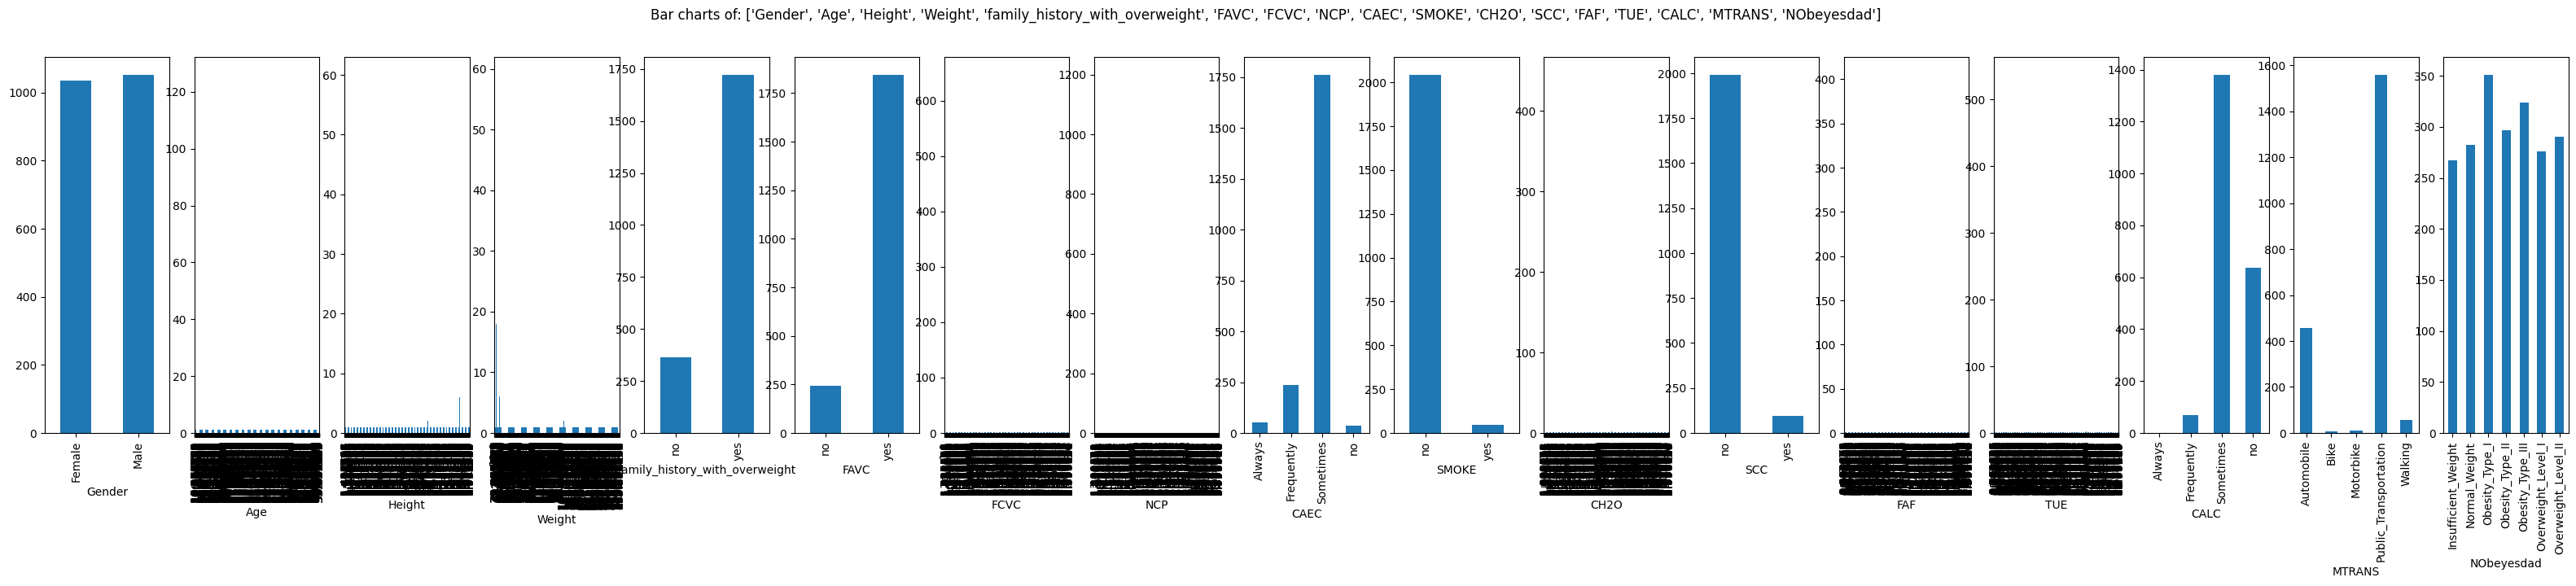

In [7]:
def PlotBarCharts(inpData, colsToPlot):

    # Generating multiple subplots
    fig, subPlot=plt.subplots(nrows=1, ncols=len(colsToPlot), figsize=(40,6))
    fig.suptitle('Bar charts of: '+ str(colsToPlot))

    for colName, plotNumber in zip(colsToPlot, range(len(colsToPlot))):
        inpData.groupby(colName).size().plot(kind='bar',ax=subPlot[plotNumber])


# Calling the function
PlotBarCharts(inpData=obesity_data, colsToPlot=['Gender','Age','Height','Weight','family_history_with_overweight','FAVC','FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS','NObeyesdad'
])

# **Visualize distribution of all the Continuous Predictor variables in the data using histograms**

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: title={'center': 'FCVC'}>,
        <Axes: title={'center': 'NCP'}>,
        <Axes: title={'center': 'CH2O'}>],
       [<Axes: title={'center': 'FAF'}>, <Axes: title={'center': 'TUE'}>,
        <Axes: >]], dtype=object)

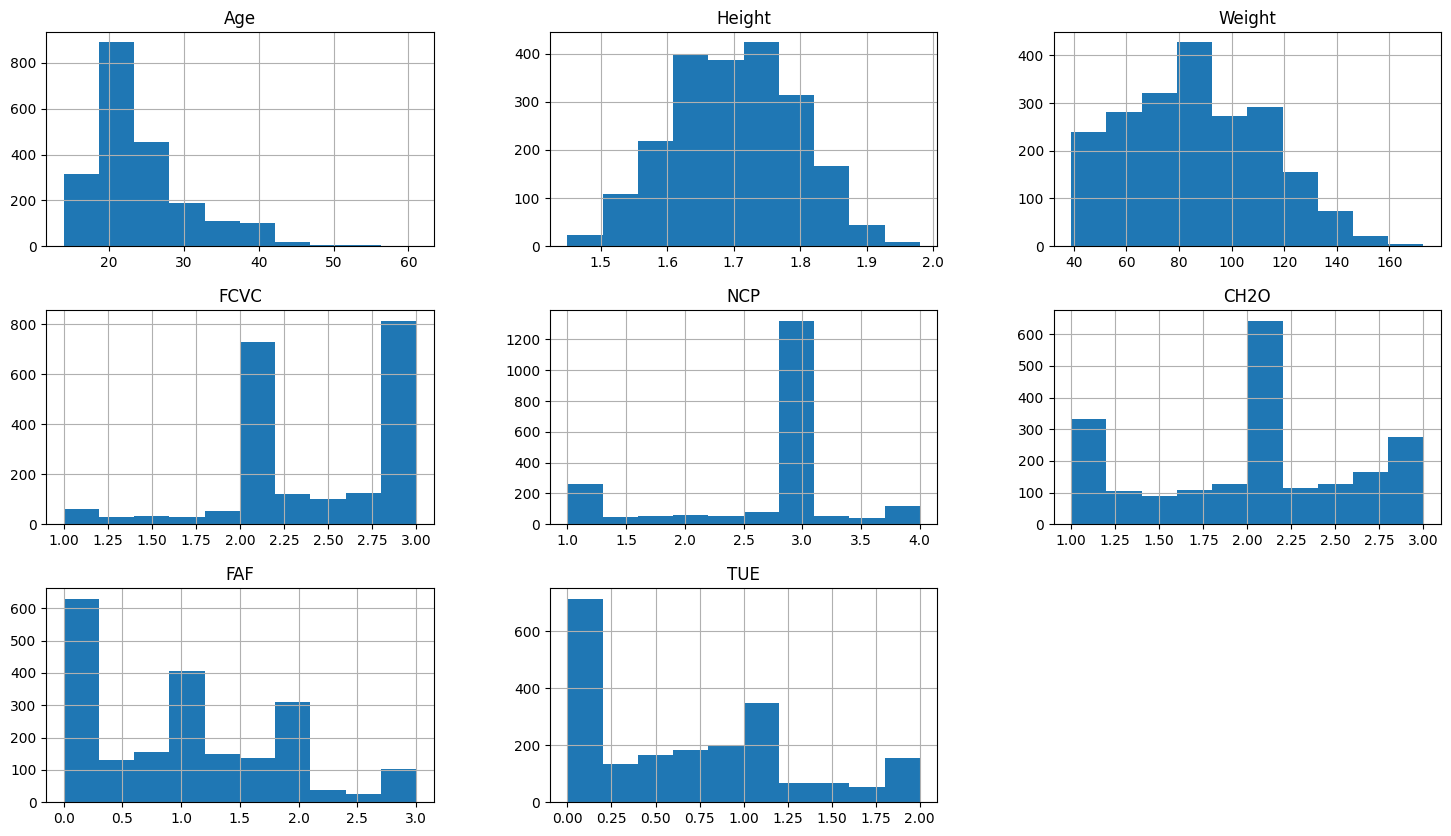

In [8]:
# Plotting histograms of multiple columns together
obesity_data.hist(['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE'], figsize=(18,10))

# **Observations:**

* Age — Right-skewed. Most people are young (18–30). Not normally distributed.
* Height — Roughly bell-shaped/normal. Good, no issues.
* Weight — Slightly right-skewed but reasonably spread. Acceptable.



 * FCVC — Clustered at whole numbers (1, 2, 3). Looks discrete rather than truly continuous. This is survey data — people answered in round numbers.
* NCP — Same issue, heavily clustered at 3.0. Very discrete-looking.
* CH2O — Similar pattern, clustered at whole numbers (1, 2, 3).
* FAF — Clustered at 0 and 1. Many people reported no physical activity.
* TUE — Heavily clustered at 0 and 1. Most people report low screen time.

# **FEATURE SELECTION**

**Target Variable:**
NObeyesdad is the obesity category of each individual (e.g., Normal Weight,
Overweight Level I, Obesity Type I, etc.). This is a multi-class
classification problem with 7 possible categories.

**Features Kept (15 features):**

Gender — Whether the person is male or female.
Age — The person's age.
Height — The person's height in meters.
Weight — The person's weight in kg. Height and Weight are among the
strongest predictors since obesity is clinically measured through body size.
Family history with overweight — Whether a family member has been
overweight. Genetics play a known role in obesity risk.
FAVC — Whether the person frequently eats high-calorie food. Directly
linked to weight gain.
FCVC — How often vegetables are eaten.
NCP — How many main meals per day.
CAEC — How often the person snacks.
CH2O — Daily water consumption. These four features together describe
the person's overall eating habits.
SCC — Whether the person tracks their calorie intake. Confirmed
statistically significant by the Chi-Square test despite appearing
weak visually.
FAF — How often the person exercises. A key factor in weight management.
TUE — Daily hours spent on screens. An indirect indicator of a sedentary lifestyle.
CALC — How often alcohol is consumed.
MTRANS — Main mode of transportation used. Reflects daily physical
activity levels.

**Features Dropped (1 feature):**

SMOKE — Dropped. Over 95% of respondents answered no, meaning this
feature barely changes across the dataset. This was further confirmed
by the Chi-Square test which found no statistically significant
relationship with obesity level.

# **Missing values treatment**

In [9]:
# Finding how many missing values are there for each column
obesity_data.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

# **Visual exploration of relationship between variables**
* Categorical Vs Continuous---- Box Plot

* Categorical Vs Categorical---- Grouped Bar Plots

# **Categorical Vs Continuous**

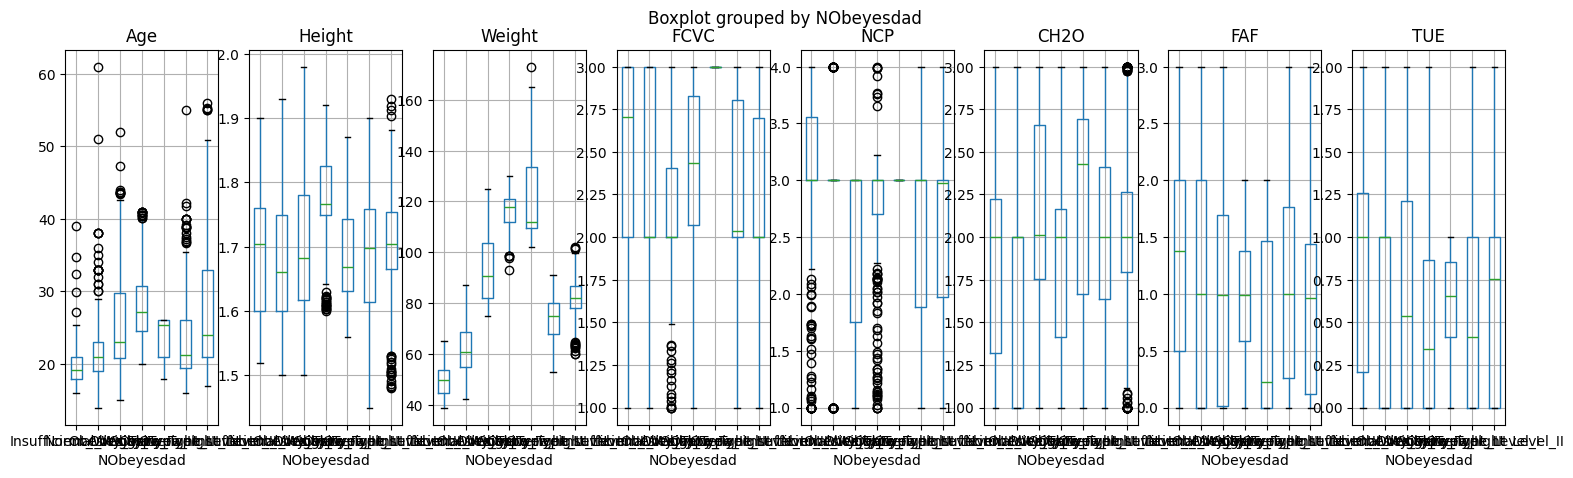

In [10]:
# Box plots for Categorical Target Variable "Clicked" and continuous predictors
ContinuousColsList= ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

fig, PlotCanvas=plt.subplots(nrows=1, ncols=len(ContinuousColsList), figsize=(18,5))

# Creating box plots for each continuous predictor against the Target Variable
for PredictorCol , i in zip(ContinuousColsList, range(len(ContinuousColsList))):
    obesity_data.boxplot(column=PredictorCol, by='NObeyesdad', figsize=(5,5), vert=True, ax=PlotCanvas[i])

# **Boxplot Interpretation - Continuous Features vs. Obesity Category**

This chart shows how each continuous feature is distributed across the 7 obesity categories. The wider the separation between boxes, the more useful that feature is for predicting obesity level.

Strong Predictors:
Weight shows a clear and consistent increase across obesity categories. Heavier individuals fall into higher obesity levels, making it the most powerful feature in the dataset. Height shows some variation across categories, making it a useful supporting feature. Age shows that younger individuals tend to appear in the Insufficient Weight category with some separation visible across groups.

Weak Predictors:
FCVC, FAF, CH2O, NCP, and TUE all show heavy overlap across obesity categories, meaning their values are similar regardless of obesity level. NCP and TUE in particular show almost no difference across categories and are candidates for removal after model training confirms their importance scores.

Conclusion:
Weight, Height, and Age are the most informative continuous features. The remaining features will be re-evaluated after training using feature importance scores.

# **Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test**

In [11]:
# Defining a function to find the statistical relationship with all the categorical variables
def FunctionAnova(inpData, TargetVariable, ContinuousPredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    print('##### ANOVA Results ##### \n')
    for predictor in ContinuousPredictorList:
        CategoryGroupLists=inpData.groupby(TargetVariable)[predictor].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)

        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])

    return(SelectedPredictors)

In [12]:
# Calling the function to check which categorical variables are correlated with target
ContinuousVariables=['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']
FunctionAnova(inpData=obesity_data, TargetVariable='NObeyesdad', ContinuousPredictorList=ContinuousVariables)

##### ANOVA Results ##### 

Age is correlated with NObeyesdad | P-Value: 3.246861907985217e-86
Height is correlated with NObeyesdad | P-Value: 2.5185012901787443e-43
Weight is correlated with NObeyesdad | P-Value: 0.0
FCVC is correlated with NObeyesdad | P-Value: 3.796507103383786e-121
NCP is correlated with NObeyesdad | P-Value: 7.1320021657369e-31
CH2O is correlated with NObeyesdad | P-Value: 4.297246743274628e-17
FAF is correlated with NObeyesdad | P-Value: 1.1554196575987729e-20
TUE is correlated with NObeyesdad | P-Value: 1.77238032713701e-08


['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# **ANOVA Results Interpretation — Continuous Features vs. Obesity Category**

The ANOVA test checks whether each continuous feature has a statistically
significant relationship with the obesity category. A P-Value below 0.05
confirms the relationship is real and not due to chance.

All 8 continuous features passed the test, meaning all of them will be
kept for model training.

Weight had the strongest relationship with a P-Value of 0.0, meaning it
is almost perfectly linked to obesity level. FCVC and Age followed as the
next strongest predictors. TUE was the weakest among the group but still
statistically significant.

Notably, NCP and TUE appeared weak in the boxplot analysis, but the ANOVA
test revealed they still carry a statistically significant relationship with
the target. This shows that visual analysis alone can be misleading, and
statistical testing is essential to confirm findings.

Conclusion:
All 8 continuous features are statistically correlated with obesity level
and will be kept for model training.

# **Relationship exploration: Categorical Vs Categorical - Grouped Bar Charts**

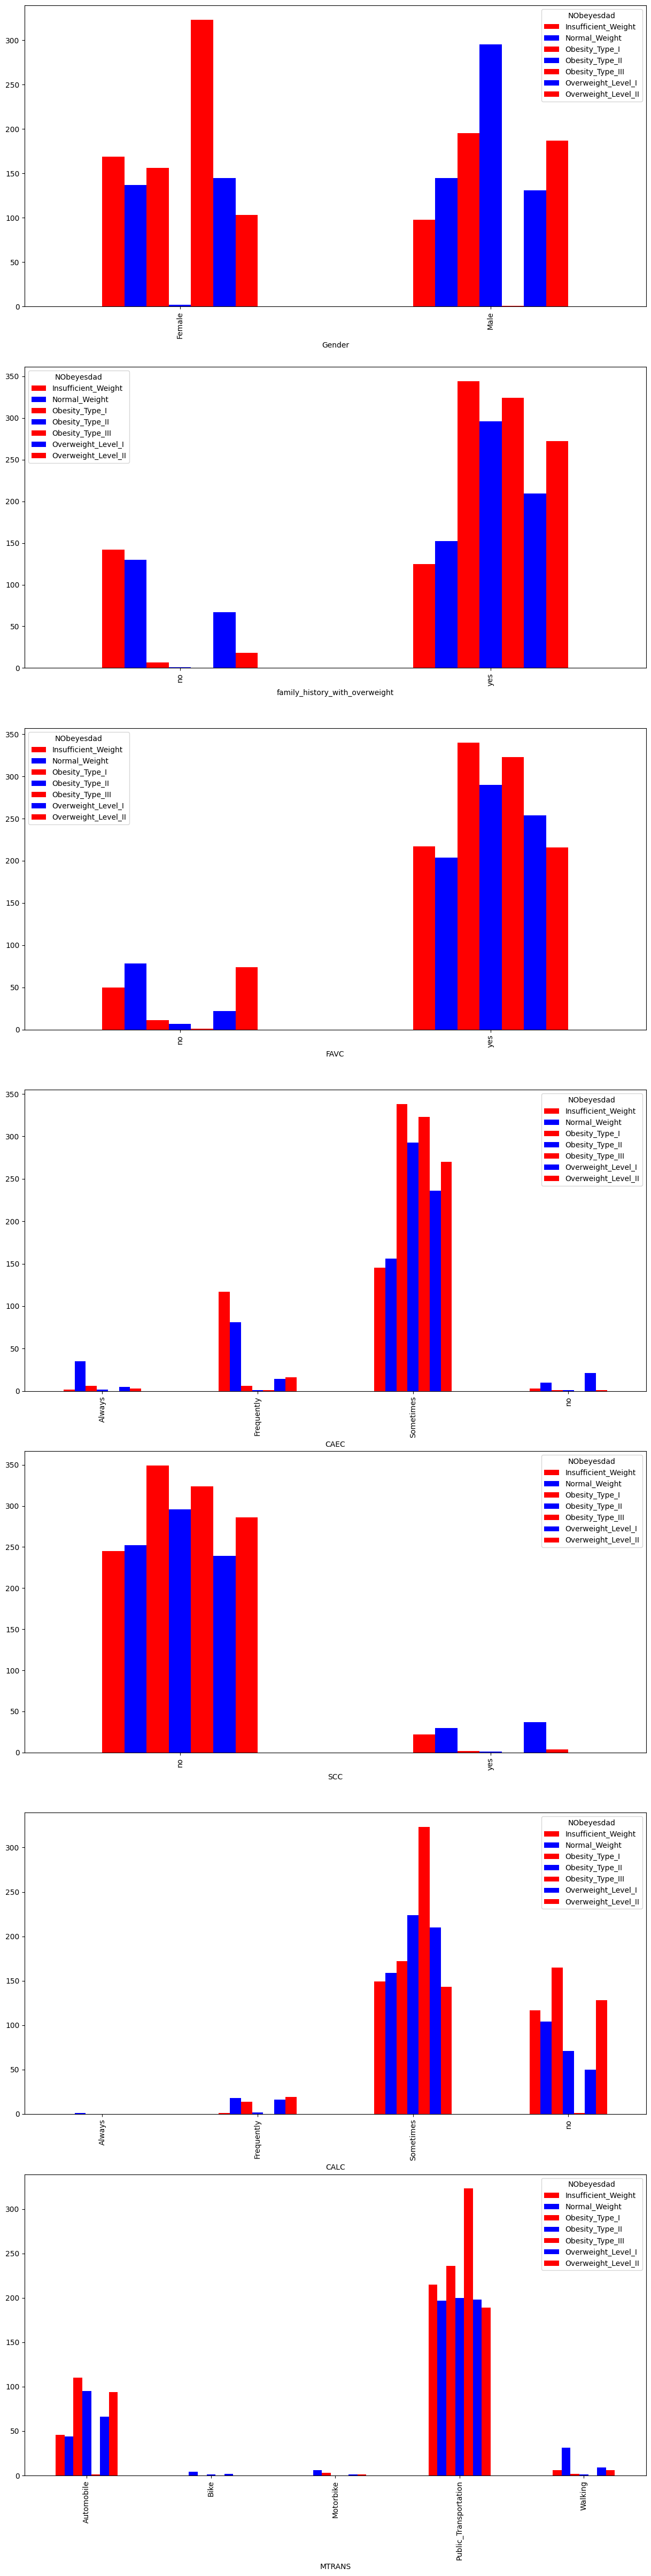

In [13]:
# Visual Inference using Grouped Bar charts
CategoricalColsList=['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS']

import matplotlib.pyplot as plt
fig, PlotCanvas=plt.subplots(nrows=len(CategoricalColsList), ncols=1, figsize=(15,60))

# Creating Grouped bar plots for each categorical predictor against the Target Variable
for CategoricalCol , i in zip(CategoricalColsList, range(len(CategoricalColsList))):
    CrossTabResult=pd.crosstab(index=obesity_data[CategoricalCol], columns=obesity_data['NObeyesdad'])
    CrossTabResult.plot.bar(color=['red','blue'], ax=PlotCanvas[i])

# **Categorical Features vs. Obesity Category - Bar Chart Interpretation**

These charts show how each categorical feature is distributed across the
7 obesity categories. Clear differences in bar heights across categories
indicate a stronger relationship with obesity level.

**Strong Predictors:**\
Family history with overweight shows a very clear pattern where people
with a family history of overweight are heavily concentrated in higher
obesity levels, making it one of the strongest categorical predictors.
FAVC confirms that people who frequently eat high caloric food dominate
the higher obesity categories. MTRANS shows meaningful differences across
transportation types and obesity levels.

**Moderate Predictors:**\
Gender, CAEC, and CALC all show some variation across obesity categories
and are worth keeping for model training.

**Weak Predictors:**\
SCC shows almost identical patterns between yes and no across all obesity
categories, suggesting it has very little predictive value. SMOKE shows
almost no variation across categories, confirming our earlier decision to
drop it after statistical testing.


**Conclusion:**\
observations. SCC is flagged as a weak predictor and will be re-evaluated
after the Chi-Square test and model feature importance scores.

# **Statistical Feature Selection (Categorical Vs Categorical) using Chi-Square Test**

In [14]:
# Writing a function to find the correlation of all categorical variables with the Target variable
def FunctionChisq(inpData, TargetVariable, CategoricalVariablesList):
    from scipy.stats import chi2_contingency

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]

    for predictor in CategoricalVariablesList:
        CrossTabResult=pd.crosstab(index=inpData[TargetVariable], columns=inpData[predictor])
        ChiSqResult = chi2_contingency(CrossTabResult)

        # If the ChiSq P-Value is <0.05, that means we reject H0
        if (ChiSqResult[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])
            SelectedPredictors.append(predictor)
        else:
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', ChiSqResult[1])

    return(SelectedPredictors)

In [15]:
CategoricalVariables= ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS']

# Calling the function
FunctionChisq(inpData=obesity_data,
              TargetVariable='NObeyesdad',
              CategoricalVariablesList= CategoricalVariables)

Gender is correlated with NObeyesdad | P-Value: 9.357967638720868e-139
family_history_with_overweight is correlated with NObeyesdad | P-Value: 3.524156108703611e-130
FAVC is correlated with NObeyesdad | P-Value: 4.0897083168071957e-47
CAEC is correlated with NObeyesdad | P-Value: 6.3012578973180325e-142
SCC is correlated with NObeyesdad | P-Value: 3.3385130651942555e-25
CALC is correlated with NObeyesdad | P-Value: 2.22093967310428e-60
MTRANS is correlated with NObeyesdad | P-Value: 3.3319887895526285e-47


['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SCC',
 'CALC',
 'MTRANS']

# **Chi-Square Test Results — Categorical Features vs. Obesity Category**

The Chi-Square test checks whether each categorical feature has a
statistically significant relationship with the obesity category.
A P-Value below 0.05 confirms the relationship is real and not due
to chance.

All 7 categorical features passed the test and will be kept for
model training.

CAEC showed the strongest relationship with the lowest P-Value,
followed closely by Gender and family history with overweight.
FAVC and MTRANS also showed strong relationships, confirming their
visual patterns from the bar charts.

The most notable finding is SCC, which appeared visually weak in
the bar charts but was confirmed statistically significant by the
Chi-Square test. This highlights the importance of statistical
testing over visual analysis alone.

Conclusion:
All 7 categorical features are statistically correlated with obesity
level and will be kept for model training.

# **Data Pre-processing for Machine Learning**

In [16]:
# Separate target variable
X = obesity_data.drop("NObeyesdad", axis=1)
y = obesity_data["NObeyesdad"]

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Identify categorical and numerical features
# Based on previous inspection, these are the categorical columns that need encoding
categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SCC",
    "CALC",
    "MTRANS",
]

numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()) # Using StandardScaler as a general good practice, can be tuned
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Create a preprocessor object using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ])

# **Defining models that we will be used**

In [17]:
models = {
    "Logistic Regression": LogisticRegression(solver="lbfgs", random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Store results
results = {}

# Split data into training and testing sets (after defining X and y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print("\n--- Model Training and Evaluation ---")
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Create a pipeline with preprocessing and model
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    report = classification_report(y_test, y_pred, target_names=le.classes_)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"\n{name} Classification Report:\n{report}")
    print(f"{name} Weighted F1-Score: {f1:.2f}")

    results[name] = {
        "report": report,
        "f1_score": f1,
        "model": pipeline # Store the trained pipeline
    }


--- Model Training and Evaluation ---

Training Logistic Regression...

Logistic Regression Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.95      0.91        87
      Normal_Weight       0.87      0.64      0.74        95
     Obesity_Type_I       0.94      0.89      0.91       105
    Obesity_Type_II       0.97      0.99      0.98        95
   Obesity_Type_III       0.98      1.00      0.99        91
 Overweight_Level_I       0.64      0.65      0.65        80
Overweight_Level_II       0.65      0.81      0.72        74

           accuracy                           0.85       627
          macro avg       0.85      0.85      0.84       627
       weighted avg       0.86      0.85      0.85       627

Logistic Regression Weighted F1-Score: 0.85

Training Decision Tree...

Decision Tree Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.9

# **Hyperparameter Tuning for Decision Tree**

In [18]:
# Hyperparameter Tuning for Decision Tree
print("\n--- Hyperparameter Tuning for Decision Tree ---")
param_grid_dt = {
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_leaf": [1, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}

grid_search_dt = GridSearchCV(Pipeline(steps=[("preprocessor", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42))]),
                              param_grid_dt, cv=5, scoring="f1_weighted", n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

best_dt_model = grid_search_dt.best_estimator_
y_pred_dt_tuned = best_dt_model.predict(X_test)
f1_dt_tuned = f1_score(y_test, y_pred_dt_tuned, average="weighted")

print(f"Best Decision Tree Parameters: {grid_search_dt.best_params_}")
print(f"Tuned Decision Tree Weighted F1-Score: {f1_dt_tuned:.2f}")
results["Decision Tree (Tuned)"] = {
    "report": classification_report(y_test, y_pred_dt_tuned, target_names=le.classes_),
    "f1_score": f1_dt_tuned,
    "model": best_dt_model
}


--- Hyperparameter Tuning for Decision Tree ---
Best Decision Tree Parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1}
Tuned Decision Tree Weighted F1-Score: 0.94


# **Hyperparameter Tuning for Random Forest**

In [19]:
# Hyperparameter Tuning for Random Forest
print("\n--- Hyperparameter Tuning for Random Forest ---")
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search_rf = GridSearchCV(
    Pipeline(steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier(random_state=42))]),
    param_grid_rf, cv=5, scoring="f1_weighted", n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average="weighted")

print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")
print(f"Tuned Random Forest Weighted F1-Score: {f1_rf_tuned:.2f}")
print(f"\nTuned Random Forest Classification Report:\n{classification_report(y_test, y_pred_rf_tuned, target_names=le.classes_)}")
results["Random Forest (Tuned)"] = {
    "report": classification_report(y_test, y_pred_rf_tuned, target_names=le.classes_),
    "f1_score": f1_rf_tuned,
    "model": best_rf_model
}


--- Hyperparameter Tuning for Random Forest ---
Best Random Forest Parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Tuned Random Forest Weighted F1-Score: 0.94

Tuned Random Forest Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93        87
      Normal_Weight       0.82      0.85      0.84        95
     Obesity_Type_I       0.99      0.96      0.98       105
    Obesity_Type_II       1.00      1.00      1.00        95
   Obesity_Type_III       1.00      1.00      1.00        91
 Overweight_Level_I       0.90      0.91      0.91        80
Overweight_Level_II       0.92      0.89      0.90        74

           accuracy                           0.94       627
          macro avg       0.94      0.94      0.94       627
       weighted avg       0.94      0.94      0.94       627



# **Hyperparameter Tuning for Gradient Boosting**

In [20]:
# Hyperparameter Tuning for Gradient Boosting
# Using RandomizedSearchCV due to the large search space
from sklearn.model_selection import RandomizedSearchCV

print("\n--- Hyperparameter Tuning for Gradient Boosting ---")
param_dist_gb = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 5, 7],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__subsample": [0.7, 0.8, 1.0]
}

random_search_gb = RandomizedSearchCV(
    Pipeline(steps=[("preprocessor", preprocessor), ("classifier", GradientBoostingClassifier(random_state=42))]),
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)
random_search_gb.fit(X_train, y_train)

best_gb_model = random_search_gb.best_estimator_
y_pred_gb_tuned = best_gb_model.predict(X_test)
f1_gb_tuned = f1_score(y_test, y_pred_gb_tuned, average="weighted")

print(f"Best Gradient Boosting Parameters: {random_search_gb.best_params_}")
print(f"Tuned Gradient Boosting Weighted F1-Score: {f1_gb_tuned:.2f}")
print(f"\nTuned Gradient Boosting Classification Report:\n{classification_report(y_test, y_pred_gb_tuned, target_names=le.classes_)}")
results["Gradient Boosting (Tuned)"] = {
    "report": classification_report(y_test, y_pred_gb_tuned, target_names=le.classes_),
    "f1_score": f1_gb_tuned,
    "model": best_gb_model
}


--- Hyperparameter Tuning for Gradient Boosting ---
Best Gradient Boosting Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05}
Tuned Gradient Boosting Weighted F1-Score: 0.96

Tuned Gradient Boosting Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.95      0.97        87
      Normal_Weight       0.92      0.86      0.89        95
     Obesity_Type_I       1.00      0.99      1.00       105
    Obesity_Type_II       1.00      1.00      1.00        95
   Obesity_Type_III       1.00      1.00      1.00        91
 Overweight_Level_I       0.86      0.95      0.90        80
Overweight_Level_II       0.97      0.99      0.98        74

           accuracy                           0.96       627
          macro avg       0.96      0.96      0.96       627
       weighted avg       0.96      0.96  

In [25]:

def evaluate_model(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)
    
    # Classification Report
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        87
           1       0.92      0.86      0.89        95
           2       1.00      0.99      1.00       105
           3       1.00      1.00      1.00        95
           4       1.00      1.00      1.00        91
           5       0.86      0.95      0.90        80
           6       0.97      0.99      0.98        74

    accuracy                           0.96       627
   macro avg       0.96      0.96      0.96       627
weighted avg       0.96      0.96      0.96       627



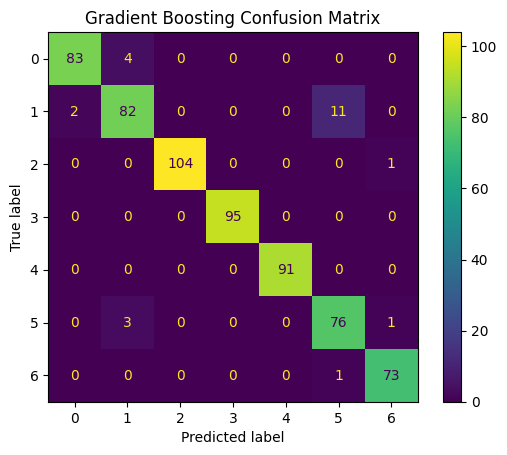

In [26]:
evaluate_model(best_gb_model, X_test, y_test, "Gradient Boosting")

The confusion matrix shows that the model performs consistently well across most obesity categories, with only minor misclassifications between neighboring classes such as Normal Weight and Overweight levels.

Final comparison of all models (baseline vs tuned)

In [21]:
# Final comparison of all models (baseline vs tuned)
print("\n--- Final Model Comparison ---")
print(f"{'Model':<35} {'Weighted F1':>12}")
print("-" * 50)
for model_name, result in results.items():
    print(f"{model_name:<35} {result['f1_score']:>12.2f}")


--- Final Model Comparison ---
Model                                Weighted F1
--------------------------------------------------
Logistic Regression                         0.85
Decision Tree                               0.94
Random Forest                               0.94
Gradient Boosting                           0.96
Decision Tree (Tuned)                       0.94
Random Forest (Tuned)                       0.94
Gradient Boosting (Tuned)                   0.96


# **Feature Importance for Random Forest**

In [22]:
print("\n--- Feature Importance (Random Forest) ---")
# Retrain Random Forest to get feature importances from the one-hot encoded features
rf_pipeline = results["Random Forest"]["model"]

# Get feature names after one-hot encoding and scaling
# This requires accessing the preprocessor steps
onehot_features = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
all_features = numerical_features + list(onehot_features)

# Get feature importances from the trained Random Forest classifier
feature_importances = rf_pipeline.named_steps["classifier"].feature_importances_

# Create a pandas Series for better visualization
importances_df = pd.Series(feature_importances, index=all_features)

print("Top 10 Most Important Features:")
print(importances_df.nlargest(10))


--- Feature Importance (Random Forest) ---
Top 10 Most Important Features:
Weight           0.293171
Age              0.093500
Height           0.089732
FCVC             0.085094
NCP              0.048684
FAF              0.044259
TUE              0.043812
CH2O             0.040397
Gender_Male      0.037377
Gender_Female    0.032777
dtype: float64


**Feature Importance & Key Drivers of Obesity**

To understand the key factors influencing obesity levels, we analyzed feature importance using a tree-based model. This provides insight into which variables contribute most to the predictions.

The results show that Weight is the most influential feature, followed by Age and Height, which is expected given how obesity is defined.

In addition, several lifestyle factors play an important role, including:

Dietary habits (e.g., vegetable consumption and number of meals)

Physical activity levels

Screen time (technology usage)

Water intake

Key Takeaway:

While physical characteristics are important, the model highlights that daily habits and lifestyle choices are key drivers of obesity levels. This suggests that obesity is strongly influenced by modifiable behaviors, which can be targeted for prevention and improvement.

**Model Selection**

Multiple classification models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Performance was assessed using the weighted F1-score to account for class imbalance.

Among all models, Gradient Boosting achieved the best performance, with a weighted F1-score of 0.96, outperforming the other models.

While both Decision Tree and Random Forest also delivered strong results (F1-score of 0.94), Gradient Boosting provided:

Higher overall predictive accuracy

Better balance across different obesity categories

Stronger generalization on the test data

Logistic Regression showed comparatively lower performance (F1-score of 0.85), suggesting that the relationship between lifestyle factors and obesity levels is better captured by non-linear models.

Final Decision:
The Gradient Boosting model was selected as the final model due to its superior performance and reliability in predicting obesity categories.